# Fase 4: Evaluación Final del Modelo Predictivo
Este notebook toma el pipeline definitivo entrenado en la fase anterior y evalúa su rendimiento. Aquí analizaremos su capacidad de predicción mediante el Reporte de Clasificación, la Matriz de Confusión y la Curva ROC.


In [8]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Configuración visual para que los gráficos se vean bien en el notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

# Configuración de rutas en Jupyter
BASE_DIR = os.path.abspath("..") 

PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
MODELS_DIR = os.path.join(BASE_DIR, "models")
REPORTS_DIR = os.path.join(BASE_DIR, "reports", "figures")

FINAL_MODEL_FILE = os.path.join(MODELS_DIR, "final_classifier.joblib")

print(f"Directorio base configurado en: {BASE_DIR}")

Directorio base configurado en: c:\Users\noram\Downloads\EV1_Google_Ads-main


### 1. Carga de Datos y Modelo
Cargamos el conjunto de prueba (`X_test`, `y_test`) y el pipeline predictivo empaquetado.

In [9]:
# Carga de datos de prueba
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test.csv"))
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test.csv")).squeeze("columns")

# Carga del modelo
if not os.path.exists(FINAL_MODEL_FILE):
    raise FileNotFoundError("¡No se encontró el modelo! Asegúrate de correr el script de entrenamiento primero.")

pipeline = joblib.load(FINAL_MODEL_FILE)
print("Datos y modelo cargados exitosamente.")

Datos y modelo cargados exitosamente.


### 2. Generación de Predicciones y Reporte de Clasificación
El F1-Score y el Reporte de Clasificación nos muestran cómo se comporta el modelo clase por clase.

In [10]:
# Generamos predicciones de clase y probabilidades
 
print("Realizando predicciones...")
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

class_names = ["No Rentable", "Rentable"]

print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN FINAL")
print("="*55)
print(classification_report(y_test, y_pred, target_names=class_names))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"Puntuación ROC-AUC: {roc_auc:.4f}")

Realizando predicciones...

REPORTE DE CLASIFICACIÓN FINAL
              precision    recall  f1-score   support

 No Rentable       0.69      0.59      0.64       332
    Rentable       0.29      0.39      0.33       142

    accuracy                           0.53       474
   macro avg       0.49      0.49      0.49       474
weighted avg       0.57      0.53      0.55       474

Puntuación ROC-AUC: 0.5125


### 3. Matriz de Confusión
Visualizaremos exactamente en qué se está equivocando el modelo. 

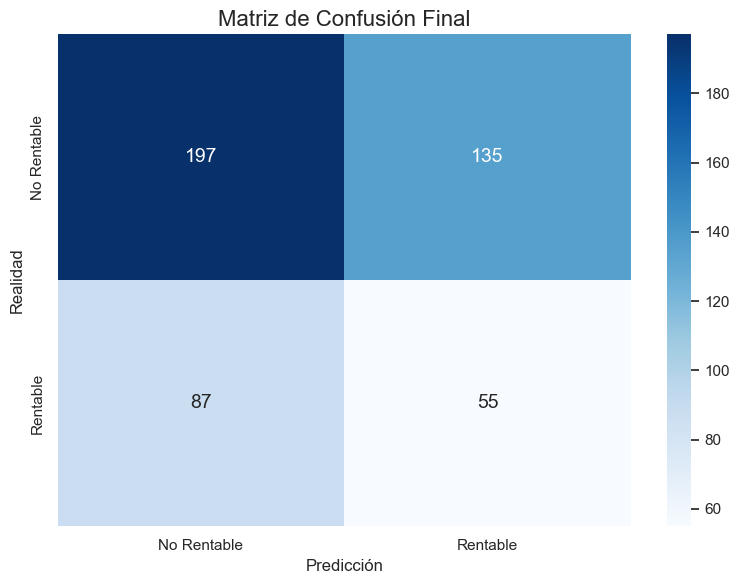

In [11]:
os.makedirs(REPORTS_DIR, exist_ok=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 14}
)
plt.title('Matriz de Confusión Final', fontsize=16)
plt.ylabel('Realidad', fontsize=12)
plt.xlabel('Predicción', fontsize=12)
plt.tight_layout()

# Guardamos la imagen y la mostramos en el notebook
cm_path = os.path.join(REPORTS_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()

### 4. Curva ROC (Capacidad de Separación)
La curva ROC nos muestra la capacidad del modelo para distinguir entre campañas rentables y no rentables en distintos umbrales de probabilidad. Mientras más cerca esté la línea naranja de la esquina superior izquierda, mejor es nuestro modelo.

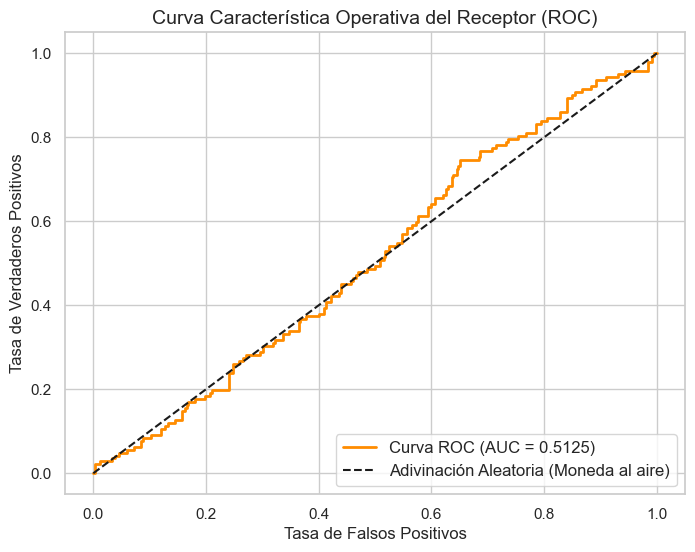

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Curva ROC (AUC = {roc_auc:.4f})", color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label="Adivinación Aleatoria (Moneda al aire)")

plt.xlabel('Tasa de Falsos Positivos', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=12)
plt.title('Curva Característica Operativa del Receptor (ROC)', fontsize=14)
plt.legend(loc="lower right", fontsize=12)

# Guardamos la imagen y la mostramos
roc_path = os.path.join(REPORTS_DIR, "roc_curve.png")
plt.savefig(roc_path, dpi=300)
plt.show()